In [ ]:
#Imports generales
import math
import numpy as np
import random

#Imports gráficos
import matplotlib.pyplot as plt
import re

#Imports AG
import deap
from deap import base, creator, tools

#Imports AC
import cellpylib as cpl

#Imports paralelización
#import multiprocessing
#from multiprocessing import Pool
from joblib import Parallel, delayed
import time
import os


Parámetros del AC
NUM_STATES -> Número de estados de cada célula
VEC_SIZE -> Vecinos considerados a cada lado de la célula
CA_NUM -> Número de autómatas utilizados en la función de fitness para testear la regla
CA_SIZE -> Tamaño del autómata
CA_TIMESTEPS -> Pasos de evolución de los autómatas

Parámetros del AG
IND_SIZE -> Tamaño de los individuos
POP_SIZE -> Tamaño de la poblacion inicial
CXPB -> Probabilidad de cruce
MUTPB -> Probabilidad de mutacion
NGEN -> Número de generaciones
STOP_CONDITION -> Valor de fitness exigido en la condición de parada
FITNESS_THRESHOLD -> Valor de fitness umbral de la función de fitness adaptativa
NUM_MUT -> Número de mutaciones realizadas en cada individuo

In [ ]:
from matplotlib.colors import ListedColormap
NUM_STATES = 3
VEC_SIZE = 1
CA_NUM = 100
CA_SIZE = 30
CA_TIMESTEPS = 90
P = 1

IND_SIZE = int(pow(NUM_STATES, 2*VEC_SIZE + 1)) 
POP_SIZE = 250
CXPB, MUTPB, NGEN = 0.9, 1, 1000

#Con estrategia mu + lambda, no hay cruce, y siempre se muta -> MUTPB = 1
STOP_CONDITION = 0.97
FITNESS_THRESHOLD = 0.75

NUM_MUT = 2 #Número de genes mutados en cada individuo

'''Patrón final deseado (bandera francesa)'''
FF = [0] * (CA_SIZE // 3) + [1] * (CA_SIZE // 3) + [2] * (CA_SIZE // 3)


'''Creador de fitness y de individuo
#Fitness con único objetivo (weights = (1.0,) y máximo'''
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

'''Especificación de genes, individuos y poblacion
Individuos ternarios, attr_int entre 0 y 2, y en forma de lista
'''
toolbox = base.Toolbox()
toolbox.register("attr_int", random.randint, 0, 2)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_int, IND_SIZE)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

'''Regla identidad por si se desea hacer el autómata probabilistico'''
def identity_rule(IND_SIZE):
    rule = [0]*IND_SIZE
    for i in range(IND_SIZE):
        ternario = entero_a_base3(i, longitud_total=2*VEC_SIZE + 1)
        rule[i] = int(ternario[VEC_SIZE])
    return rule
        

'''Creador de regla de transición en el formato requerido por CellPyLib a partir de diccionario de reglas.'''
def create_transition_rule(rule_dict, probability, ca_size):
    id_rule = identity_rule(IND_SIZE)
    def my_rule(cells, r, t):
        if r == 0: #Frontera fija -> célula izquierda es 0
            return 0
        if r == ca_size - 1: #Frontera fija -> célula derecha es 2
            return 2
        if random.random() < probability: #Construcción de la regla general con probabilidad P
            key = ''.join(str(int(c)) for c in cells)
            return rule_dict[key]
        else:
            key = ''.join(str(int(c)) for c in cells) #Caso de regla identidad con probabilidad 1 - P
            key_int = int(key, 3)
            return id_rule[key_int]  
            
    return my_rule

'''Generación aleatoria de autómatas, teniendo en cuenta la frontera fija'''
def generate_CAs(ca_num, num_states, ca_size):
    CAs = [None] * ca_num
    for i in range(ca_num):
        ca = [0] 
        ca_aux = np.random.randint(0, num_states, size=ca_size - 2)
        ca.extend(ca_aux)
        ca.append(2)
        CAs[i] = np.expand_dims(ca, axis=0)
    return CAs

'''Conversión de enteros a base3, necesaria para determinar los vecindarios asociados a cada índice de las reglas'''
def entero_a_base3(numero, longitud_total=0):
    if numero == 0:
        return "0".zfill(longitud_total)

    ternario = ""
    n = numero

    while n > 0:
        residuo = n % 3
        ternario = str(residuo) + ternario 
        n = n // 3

    return ternario.zfill(longitud_total)

'''Creación del diccionario de reglas. Recibe un individuo (array de elementos ternarios), y para cada elemento
calcula su índice en ternario (vecindario) y le asigna el nuevo estado de la célula central'''
def gen_rule_dict(individual):
    rule_dict = {}
    for i in range(len(individual)):
        ternario = entero_a_base3(i, longitud_total=2*VEC_SIZE + 1)
        rule_dict[ternario] = individual[i]

    return rule_dict

'''Evolucion de los autómatas de la lista CAs mediante mi_regla'''
def evolved_CAs(CAs, mi_regla):
    evolved_CAs = []
    for i in range(len(CAs)):
        evolved_CA = cpl.evolve(CAs[i], timesteps=CA_TIMESTEPS, apply_rule=mi_regla, r=VEC_SIZE)
        evolved_CAs.append(evolved_CA)

    return evolved_CAs

'''Generación aleatoria de autómatas'''
def generate_CAs(ca_num, num_states, ca_size_1, ca_size_2):
    CAs = []
    for i in range(ca_num):
        ca = np.random.randint(0, NUM_STATES, size=(ca_size_1, ca_size_2))
        ca = np.expand_dims(ca, axis=0)
        CAs.append(ca)
    return CAs

'''Funcion que genera la regla a partir de un individuo, evoluciona los autómatas con esa regla y devuelve el valor de fitness 
correspondiente, en este caso, la proporcion de células que están bien colocadas respecto al estado objetivo'''
def rule_and_evolve(ca_num, individual, CAs, ca_size):
    #Diccionario de reglas
    rule_dict = gen_rule_dict(individual)
    mi_regla = create_transition_rule(rule_dict, P, ca_size)
    
    #Evolución
    CAs = evolved_CAs(CAs, mi_regla)

    #Estudiamos los resultados
    common_cells = []
    for ca in CAs:
        common_cells.append(np.sum(ca[-1] == FF)/ca_size)
        
    return np.sum(common_cells)/ ca_num 

'''Funcion de fitness adaptativa:
Genera 20 autómatas aleatoriamente, determina la regla asociada al individuo y los evoluciona con esa regla. 
Si esa regla acierta, de media, en más del 75% de las células, se repite el proceso con 100 autómátas.
Si no, se devuelve el porcentaje por debajo de 75%. De esta forma, se evita evaluar reglas que no son tan buenas
y se gana eficiencia temporal'''

def evaluate_FF(individual):

    CAs = generate_CAs(CA_NUM//5, NUM_STATES, CA_SIZE)

    res = rule_and_evolve(CA_NUM//5, individual, CAs, CA_SIZE)

    if res < FITNESS_THRESHOLD:
        return (res,)
        
    CAs = generate_CAs(CA_NUM, NUM_STATES, CA_SIZE)
    
    res = rule_and_evolve(CA_NUM, individual, CAs, CA_SIZE)

    return (res,)

'''Funcion de mutacion personalizada: selecciona un gen al azar, lo cambia a uno distinto aleatoriamente y devuelve el individuo modificado'''
def mutChangeGen(individual):
    gen = random.randint(0, len(individual) - 1)
    
    val = individual[gen]

    if val == 0:
        new_val = random.choice([1, 2])
    elif val == 1:
        new_val = random.choice([0, 2])
    else: 
        new_val = random.choice([0, 1])
        
    individual[gen] = new_val
    
    return individual

'''Configuración del cruce y la selección (aunque no sea necesario), selecciona la mutacion personalizada (mutChangeGen) y
registra la función de evaluacion personalizada del algoritmo '''
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", mutChangeGen)
toolbox.register("select", tools.selTournament, tournsize=GA.tournament_size)
toolbox.register("evaluate", evaluate_FF)

def GA():
    '''generación aleatoria de la poblacion'''
    pop = toolbox.population(n=POP_SIZE)

    '''Evaluación de toda la población paralelamente mediante la libreria joblib y asignacion de cada fitness a su individuo'''
    print('Iniciando cálculo de fitness', flush = True)
    fitnesses = Parallel(n_jobs=-1)(delayed(toolbox.evaluate)(ind) for ind in pop)
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit
    print('Cálculo de fitness terminado', flush = True)

    
    for g in range(NGEN):
        print(f'--- Iniciando Generación {g} ---', flush=True)

        '''Estrategia clásica comentada'''
        '''Selección:
        Dejamos que el 20% de los mejores individuos pasen a la siguiente generación'''
        elites = list(map(toolbox.clone, tools.selBest(pop, k= round(0.2*POP_SIZE))))
        
        '''Hacemos selección por torneo para construir el 80% restante de la próxima generacion'''
        offspring = toolbox.select(pop, len(pop) - round(0.2*POP_SIZE))
        offspring = list(map(toolbox.clone, offspring))

        '''Cruce y mutación'''
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < CXPB:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < MUTPB:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        '''Evaluar paralelamente individuos con fitness inválido, es decir, indiviudos cuyo fitness no se ha calculado todavía.'''
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = Parallel(n_jobs=-1)(delayed(toolbox.evaluate)(ind) for ind in invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        '''Nueva población: 
        Construimos la población nueva juntando el 20% de elitismo (elites) con el 80% de selección por torneo (offspring)'''
        pop[:] = elites + offspring

        
        '''Estrategia mu + lambda'''
        '''Clonamos la poblacion y mutamos cada individuo dos veces'''
        '''offspring = list(map(toolbox.clone, pop))
        for mutant in offspring:
            for i in range(NUM_MUT):
                toolbox.mutate(mutant)
            del mutant.fitness.values'''

        '''Calculamos los nuevos fitness'''
        '''invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = Parallel(n_jobs=-1)(delayed(toolbox.evaluate)(ind) for ind in invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit'''


        '''Para cada individuo y su correspondiente mutante, sleccionamos aquel con mayor fitness'''
        '''pop_aux = []
        for ind, mut in zip(pop, offspring):
            if ind.fitness.values[0] > mut.fitness.values[0]:
                pop_aux.append(ind)
            else:
                pop_aux.append(mut)
        pop = pop_aux'''

        
        '''Descartamos el 25% de las peores reglas y las añadimos aleatoriamente -> generacion de diversidad en la población'''
        '''pop_aux1 = tools.selBest(pop_aux, k = round(POP_SIZE*0.75))
        pop_aux2 = toolbox.population(n=POP_SIZE - round(POP_SIZE*0.75))
        fitnesses = Parallel(n_jobs=-1)(delayed(toolbox.evaluate)(ind) for ind in pop_aux2)
        for ind, fit in zip(pop_aux2, fitnesses):
            ind.fitness.values = fit
            
        pop[:] = pop_aux1 + pop_aux2'''


        top = tools.selBest(pop, 3)
        print(f"--- Gen {g} Completada: Max Fitness = {top[0].fitness.values[0]:.2f}", flush=True)
        print(top[0])
        if top[0].fitness.values[0] >= STOP_CONDITION: #Estudiar condición de parada
            print(f"Parado en la generación {g} con fitness {top[0].fitness.values[0]}")
            return top

    return tools.selBest(pop, 3)

In [ ]:
'''Código de colores'''
AZUL_CLARO   = "\033[94m" # Para el estado 0
BLANCO_BRILLANTE = "\033[97m" # Para el estado 1
ROJO_BRILLANTE   = "\033[91m" # Para el estado 2
RESET      = "\033[0m"  # Para resetear el color al final

'''Funcion que, dada una regla, la muestra gráfciamente con las configuraciones de vecinos y los colores correspondientes'''
def dibujar_regla(regla):
    
    simbolo_0 = "■" # Azul
    simbolo_1 = "■" # Blanco
    simbolo_2 = "■" # Rojo
    
    # Mapeo de estados (como string) a sus símbolos y códigos de color ANSI
    simbolos_map = { 
        '0': f"{AZUL_CLARO}{simbolo_0}{RESET}", 
        '1': f"{BLANCO_BRILLANTE}{simbolo_1}{RESET}", 
        '2': f"{ROJO_BRILLANTE}{simbolo_2}{RESET}"
    }
    
    print("--- Catálogo de Reglas del AC (Índice -> Configuración -> Resultado) ---")
    
    longitud_vecindad = 2 * VEC_SIZE + 1

    for indice in range(IND_SIZE):
        
        # 1. Obtener la configuración (en base 3)
        config_ternaria_str = entero_a_base3(indice, longitud_vecindad)
        
        # 2. Convertir a símbolos visuales
        config_visual = "".join([simbolos_map[c] for c in config_ternaria_str])
        
        # 3. Obtener el resultado
        resultado = regla[indice] # El resultado será 0, 1, o 2
        resultado_visual = simbolos_map[str(resultado)]
        
        # 4. Imprimir la línea (ajusta el padding '04d' si IND_SIZE es muy grande)
        print(f"Índice {indice:04d}:   {config_visual}   ->   {resultado_visual}")

'''Llama al algoritmo y hace un test con las 3 mejores reglas'''
if __name__ == "__main__":
    top3 = GA()
    CA_NUM_TEST = 250
    for individual in top3:
        regla = np.array(individual)
        dibujar_regla(regla)
        
        CAs = generate_CAs(CA_NUM_TEST, NUM_STATES, CA_SIZE)

        rule_dict = gen_rule_dict(individual)
        mi_regla = create_transition_rule(rule_dict, P, CA_SIZE)

        '''Evolucion de los autómatas de prueba con la regla (ahora sí, en paralelo)'''
        CAs = Parallel(n_jobs=-1)(delayed(cpl.evolve)(CAs[i], timesteps=CA_TIMESTEPS, apply_rule=mi_regla, r=VEC_SIZE) for i in range(len(CAs)))

        '''Estudio del rendimiento de la regla'''
        common_cells = []
        for ca in CAs:
            common_cells.append(np.sum(ca[-1] == FF)/CA_SIZE)
                
        porcentaje_exito = (np.sum(common_cells) / CA_NUM_TEST) * 100
        print("\n" + "*"*30)
        print(f"  RENDIMIENTO DE LA REGLA:")
        print(f"  FITNESS:  {porcentaje_exito:.2f}%")
        print("*"*30 + "\n")

        
        '''Graficación de la evolucion de los autómatas'''
        colores_ternarios = ['blue', 'white', 'red'] 
        cmap_personal = ListedColormap(colores_ternarios)
        
        for i in range(len(CAs)):
            plt.figure(figsize=(8, 4))
            plt.imshow(CAs[i], cmap=cmap_personal, interpolation='nearest', aspect='auto')
            plt.xlabel("Celda")
            plt.ylabel("Tiempo")
            plt.title(f"Evolución del autómata CA {i}")
            plt.show()

In [ ]:
'''Seleccion 80/20, cruce, mutación con prob baja, fitness adaptativo'''
regla_0 = [0, 0, 0, 2, 1, 2, 0, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 0, 0, 1, 1, 0, 0, 1, 0, 2]
'''Fitness alcanzado: 80%, 74%, 71%'''

'''Estrategia mu + lambda, fitness adaptativo, stop_condition = 80%, 500 generaciones'''
regla_1 = [0, 0, 2, 0, 1, 1, 1, 2, 2, 1, 1, 1, 0, 1, 1, 2, 0, 2, 2, 2, 1, 0, 2, 2, 0, 1, 2]
'''Fitness alcanzado: 80%, 82%, 80%, generaliza bien'''

'''Estrategia mu + lambda, 1000 generaciones'''
regla_2 = [0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 0, 0, 1, 1, 0, 1, 2, 2, 2, 1, 1, 2, 2, 0, 1, 2]
'''Fitness alcanzado: 84%, 84%, 84%, TOP'''

'''Estrategia mu + lambda, 2000 generaciones'''
regla_3 = [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 1, 0, 1, 1, 0, 1, 2, 0, 2, 0, 0, 2, 2, 1, 0, 2]
'''Fitness alcanzado: 91%, 94%, 95%'''

'''Comparamos el rendimiento de ambas reglas con 250 autómátas de distintos tamaños'''
num_automata = 250
CA_SIZE_LIST = [30, 60, 90]
CA_TIMESTEPS_LIST = [75, 140, 200]
reglas = [regla_3]

for individual in reglas:
    dibujar_regla(individual)
    for j in range(len(CA_SIZE_LIST)):
        FF = [0] * (CA_SIZE_LIST[j] // 3) + [1] * (CA_SIZE_LIST[j] // 3) + [2] * (CA_SIZE_LIST[j] // 3)
        
        CAs = generate_CAs(num_automata, NUM_STATES, CA_SIZE_LIST[j])
    
        rule_dict = gen_rule_dict(individual)
        mi_regla = create_transition_rule(rule_dict, P, CA_SIZE_LIST[j])

        
        CAs = Parallel(n_jobs=-1)(delayed(cpl.evolve)(CAs[i], timesteps=CA_TIMESTEPS_LIST[j],apply_rule=mi_regla,r=VEC_SIZE) for i in range(len(CAs)))
    
        #Estudiamos los resultados
        common_cells = []
        for ca in CAs:
            common_cells.append(np.sum(ca[-1] == FF)/CA_SIZE_LIST[j])
                
        porcentaje_exito = (np.sum(common_cells) / num_automata) * 100
        print("\n" + "*"*30)
        print(f"  RENDIMIENTO DE LA REGLA:")
        print(f"  FITNESS:  {porcentaje_exito:.2f}%")
        print("*"*30 + "\n")
    
        # 4. Definir colores y graficar
        colores_ternarios = ['blue', 'white', 'red'] 
        cmap_personal = ListedColormap(colores_ternarios)
        
        for i in range(len(CAs)):
            plt.figure(figsize=(8, 4))
            plt.imshow(CAs[i], cmap=cmap_personal, interpolation='nearest', aspect='auto')
            plt.xlabel("Celda")
            plt.ylabel("Tiempo")
            plt.title(f"Evolución del autómata CA {i}")
            plt.show()
    

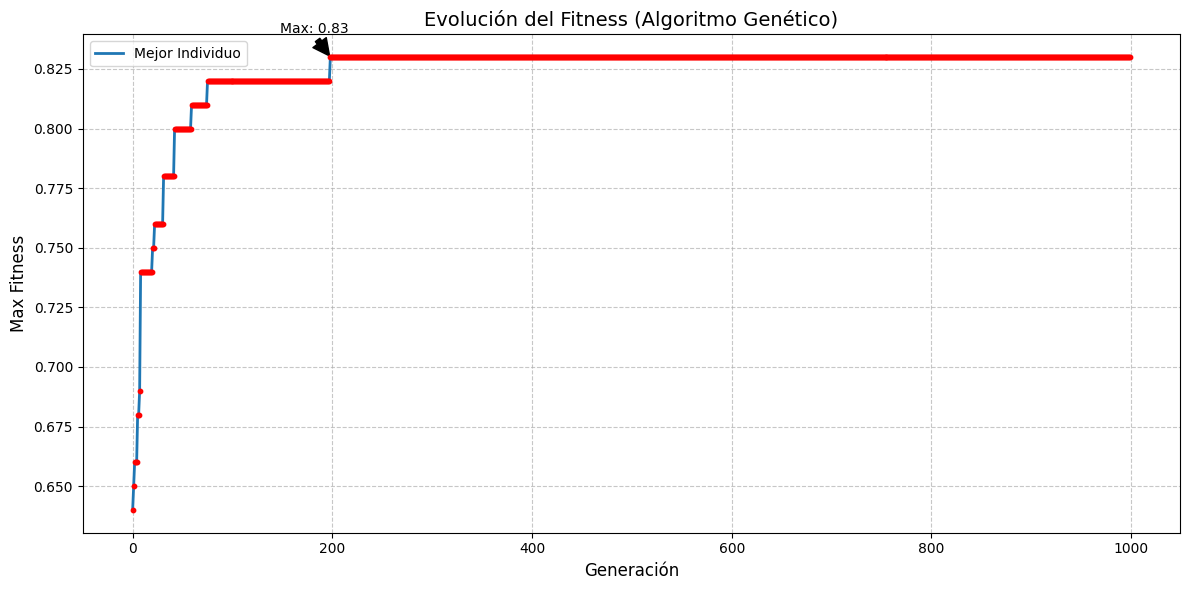

In [75]:
log_data = """
Incluir la salida aquí
"""

# 1. Extraer datos usando Expresiones Regulares (Regex)
# Buscamos el patrón "Gen [NUMERO] ... Fitness = [DECIMAL]"
patron = r"Gen (\d+) Completada: Max Fitness = (\d+\.\d+)"
coincidencias = re.findall(patron, log_data)

# 2. Convertir los textos extraídos a listas numéricas
generaciones = [int(dato[0]) for dato in coincidencias]
fitness_values = [float(dato[1]) for dato in coincidencias]

# 3. Configuración de la Gráfica
plt.figure(figsize=(12, 6)) # Tamaño de la imagen
plt.plot(generaciones, fitness_values, 
         linewidth=2, 
         color='#1f77b4', # Azul estándar
         label='Mejor Individuo')

# Añadir puntos en los momentos donde cambia el fitness (escalones)
# Esto ayuda a visualizar cuándo ocurrieron las mutaciones exitosas
plt.scatter(generaciones, fitness_values, color='red', s=10, zorder=5)

# 4. Etiquetas y Estilo
plt.title('Evolución del Fitness (Algoritmo Genético)', fontsize=14)
plt.xlabel('Generación', fontsize=12)
plt.ylabel('Max Fitness', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()

# Mostrar valor final
max_val = max(fitness_values)
max_gen = generaciones[fitness_values.index(max_val)]
plt.annotate(f'Max: {max_val}', xy=(max_gen, max_val), xytext=(max_gen-50, max_val+0.01),
             arrowprops=dict(facecolor='black', shrink=0.05))

# 5. Mostrar
plt.tight_layout()
plt.show()